In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ονοματεπώνυμο: Πέτρος Ματσούκης, ΑΜ: 1115202100099, Ονοματεπώνυμο: Γιώργος Κορύλλος, ΑΜ: 1115202100069

In [ ]:
#GIA TO EROTIMA 1.11

#I will change column 'amenities' in cleaning because I won't create the same csv twice
def clean_amenities(df):
  df['amenities'] = df['amenities'].str.replace('"', '')
  df['amenities'] = df['amenities'].str.replace('{', '')
  df['amenities'] = df['amenities'].str.replace('}', '')

  #each service will belong to a category
  all_dict = {}
  kitchen_list = ['Microwave', 'Coffee maker', 'Refrigerator', 'Dishwasher', 'Oven', 'Stove', 'Kitchen', 'Full kitchen', 'Convection oven', 'Kettle',
                  'kettle', 'Mini fridge', 'Espresso machine', 'Double oven', 'Wine cooler', 'Steam oven', 'Gas oven', 'Freezer', 'Kitchenette',
                  'Dishes and silverware', 'Cooking basics', 'Breakfast', 'Breakfast table', 'BBQ grill', 'Table', 'table']

  for item in kitchen_list:
    all_dict[item] = 'kitchen'

  bathroom_list = ['Stand alone steam shower', 'Bidet', 'Heated towel rack', 'En suite bathroom', 'Soaking tub', 'Roll-in shower', 'Toilet paper',
                  'Toilet', 'Rain shower', 'Bathroom essentials', 'Bathtub', 'Walk-in shower', 'Body soap', 'Bath towel', 'Hot water', 'Hot water kettle', 'First aid kit',
                  'Shampoo', 'Essentials', 'Touchless faucets', 'Hammock', 'Private pool', 'Sauna', 'Alfresco bathtub', 'Shared gym', 'Sun loungers',
                  'Jetted tub', 'Beach view', 'Private hot tub', ' toilet']

  for item in bathroom_list:
    all_dict[item] = 'bathroom'

  electricity_and_technology_list = ['Cable TV', 'Smart TV', 'TV', 'Air conditioning', 'Elevator', 'Buzzer wireless intercom', 'Washer Dryer',
                                    'Hair dryer', 'Iron', 'Washer', 'Dryer', 'Game console', 'DVD player', 'Keypad', 'Sound system',
                                    'High-resolution computer monitor', 'Printer', 'Fax machine', 'Central air conditioning', 'Ceiling fan',
                                    'Projector and screen', 'Amazon Echo', 'Warming drawer', 'Heat lamps', 'Internet', 'Wifi', 'Heating',
                                    'Ethernet connection', 'Pocket wifi', 'EV charger', 'Netflix', 'HBO GO', 'Cable', 'Buzzer/wireless intercom']

  for item in electricity_and_technology_list:
    all_dict[item] = 'electricity_and_technology'

  pets_and_children_list = ['Family/kid friendly', 'Patio or balcony', 'Host greets you', 'Long term stays allowed', 'Childrens book toy', 'Crib',
                                      'Pack n Play travel crib', 'Children’s dinnerware', 'Changing table', 'Outlet covers', 'Baby bath',
                                      'Babysitter recommendations', 'Baby monitor', 'Table corner guards', 'High chair', 'Stair gates', 'Dog(s)', 'Cat(s)',
                                      'Pets live on this property', 'Pets allowed', 'Pet', 'pet', 'Children’s books and toys']

  for item in pets_and_children_list:
    all_dict[item] = 'for_pets_and_children'

  disabled_list = ['Electric profiling bed', 'Ground floor access', 'Disabled parking spot', 'Fixed grab bars for shower', 'Wide clearance shower toilet',
                  'Wide clearance to shower', 'Accessible-height toilet', 'Wide clearance toilet', 'Fixed grab bar shower', 'Wide entryway',
                  'Wheelchair accessible', 'Flat path to front door', 'Wide hallway clearance', 'Accessible-height bed', 'Handheld shower head',
                  'Wide doorway', 'Step-free access', 'Wide clearance to bed', 'Single level home', 'Shower chair', 'Bath chair', 'bath chair',
                  'Well-lit path to entrance', 'Bathtub with bath chair', 'Fixed grab bars for toilet']

  for item in disabled_list:
    all_dict[item] = 'for_disabled'

  bedroom_list = ['Hangers', 'Bed linens', 'Extra pillows and blankets', 'Room-darkening shades', 'Indoor fireplace', 'Private living room', 'Fire pit',
                  'Bedroom comforts', 'Firm mattress', 'Memory foam mattress', 'Murphy bed', 'Pillow-top mattress', 'Mudroom', 'Day bed',
                  'Standing valet', 'Ironing Board']

  for item in bedroom_list:
    all_dict[item] = 'bedroom'

  security_list = ['Safety card', 'Self check-in', 'Fire extinguisher', '24 hour check', 'Smoke detector', 'Carbon monoxide detector',
                  'Lock on bedroom door', 'Self check Lockbox', 'Private entrance', 'Window guards', 'Doorman', 'Fireplace guards',
                  'Smart lock', 'Lockbox']

  for item in security_list:
    all_dict[item] = 'security'

  other_list = ['Luggage dropoff allowed', 'Cleaning before checkout', 'Smoking allowed', 'Building staff', 'Suitable for events', 'Well lit path entrance',
                'Formal dining area', 'Exercise equipment', 'Heated floors', 'Laptop friendly workspace', 'Lake access', 'Beachfront', 'Waterfront',
                'Outdoor parking', 'Pool', 'Ski', 'Ski-in/Ski-out', 'Mountain view', 'Terrace', 'Gym', 'Balcony', 'Outdoor seating', 'Terrace Balcony', 'Hot tub',
                'Beach essentials', 'Free parking on premises', 'Free street parking', 'Paid parking on premises', 'Paid parking off premises', 'Garden or backyard', '24-hour check-in',
                'Pack ’n Play/travel crib', 'Other', 'Other pet(s)']

  for item in other_list:
    all_dict[item] = 'other'

  exc1 = 'translation missing: en.hosting_amenity_49'
  exc2 = 'translation missing: en.hosting_amenity_50'

  for index, row in df.iterrows():
    #every 'amenities' row becomes a list
    words = df.loc[index, 'amenities'].split(',')

    #remove the translation missing
    if exc1 in words:
      words.remove(exc1)
    if exc2 in words:
      words.remove(exc2)

    #change each word with its category
    for i in range(0,len(words)):
      words[i] = all_dict[words[i]]

    #throw away duplicates
    words_set = set(words)
    words = list(words_set)

    #sort each row
    words = sorted(words)

    #replace it in df
    df.loc[index,'amenities'] = str(words).replace('[', '').replace(']', '')
  return df

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
import random
import numpy as np
from wordcloud import WordCloud
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from nltk.metrics import BigramAssocMeasures
from nltk.collocations import BigramCollocationFinder


def cleaning(df):

  #bedrooms, beds, bathrooms, accommodates must be from 1 to 15 and all integers
  for col in df.columns:
    if col in ['bedrooms', 'beds', 'bathrooms', 'accommodates']:
      df[col] = pd.to_numeric(df[col], errors='coerce')
      df.loc[(df[col] < 1) | (df[col] >= 16), col] = np.nan

  #minimum nights must be from 1 to 30
  df = df.loc[(df['minimum_nights'] <= 30) & (df['minimum_nights'] > 0)]

  #availability_365 must be from 0 to 365
  df = df.loc[(df['availability_365'] >= 0) & (df['availability_365'] <= 365)]

  #column 'bathrooms' has nothing
  for col in df.columns:
    if col in ['host_has_profile_pick', 'host_identity_verified', 'instant_bookable']:
      df = df.loc[(df[col] == 't') | (df[col] == 'f')]

  df = df.dropna()
  df = df.drop_duplicates()

  df['host_id'] = df['host_id'].astype(int)
  df = clean_amenities(df)
  #make them integers
  for col in df.columns:
    if col in ['bedrooms', 'beds', 'bathrooms', 'accommodates']:
      df[col] = df[col].astype(int)
  #get rid of $ in column 'price' and convert all prices to numbers
  df['price'] = df['price'].str.replace('$', '')
  df['price'] = pd.to_numeric(df['price'], errors='coerce')
  return df

In [ ]:
listings_february_2019 = '/content/drive/MyDrive/2019/febrouary/listings.csv'
listings_march_2019 = '/content/drive/MyDrive/2019/march/listings.csv'
listings_april_2019 = '/content/drive/MyDrive/2019/april/listings.csv'
listings0_february_2019 = '/content/drive/MyDrive/2019/febrouary/listings0.csv'
listings0_march_2019 = '/content/drive/MyDrive/2019/march/listings0.csv'
listings0_april_2019 = '/content/drive/MyDrive/2019/april/listings0.csv'
reviews_february_2019 = '/content/drive/MyDrive/2019/febrouary/reviews.csv'
reviews_march_2019 = '/content/drive/MyDrive/2019/march/reviews.csv'
reviews_april_2019 = '/content/drive/MyDrive/2019/april/reviews.csv'

columns = ['id', 'zipcode','transit','bedrooms','beds','review_scores_rating',
           'number_of_reviews','neighbourhood','neighbourhood_cleansed','name','latitude','longitude',
           'last_review','instant_bookable','host_id', 'host_since','host_response_rate',
           'host_identity_verified','host_has_profile_pic','first_review',
           'description','city','cancellation_policy','bed_type','bathrooms',
           'accommodates','amenities','room_type','property_type','price',
           'availability_365','minimum_nights']

listings_february_2019_df = pd.read_csv(listings_february_2019, usecols=columns)
listings_march_2019_df = pd.read_csv(listings_march_2019, usecols=columns)
listings_april_2019_df = pd.read_csv(listings_april_2019, usecols=columns)
listings0_february_2019_df = pd.read_csv(listings0_february_2019)
listings0_march_2019_df = pd.read_csv(listings0_march_2019)
listings0_april_2019_df = pd.read_csv(listings0_april_2019)
reviews_february_2019_df = pd.read_csv(reviews_february_2019, nrows = 3000)
reviews_march_2019_df = pd.read_csv(reviews_march_2019, nrows = 3000)
reviews_april_2019_df = pd.read_csv(reviews_april_2019, nrows = 3000)

#extra column for month
listings_february_2019_df['month'] = 'february'
listings_march_2019_df['month'] = 'march'
listings_april_2019_df['month'] = 'april'

listings_2019_df = pd.concat([listings_february_2019_df, listings_march_2019_df,
                              listings_april_2019_df], ignore_index=True)
listings0_2019_df = pd.concat([listings0_february_2019_df,listings0_march_2019_df,
                              listings0_april_2019_df], ignore_index=True)
reviews_2019_df = pd.concat([reviews_february_2019_df, reviews_march_2019_df,
                              reviews_april_2019_df], ignore_index=True)

#clean
listings_2019_df = cleaning(listings_2019_df)

#make one csv for all months in a year
listings_2019_df.to_csv('train_2019.csv', index=False)

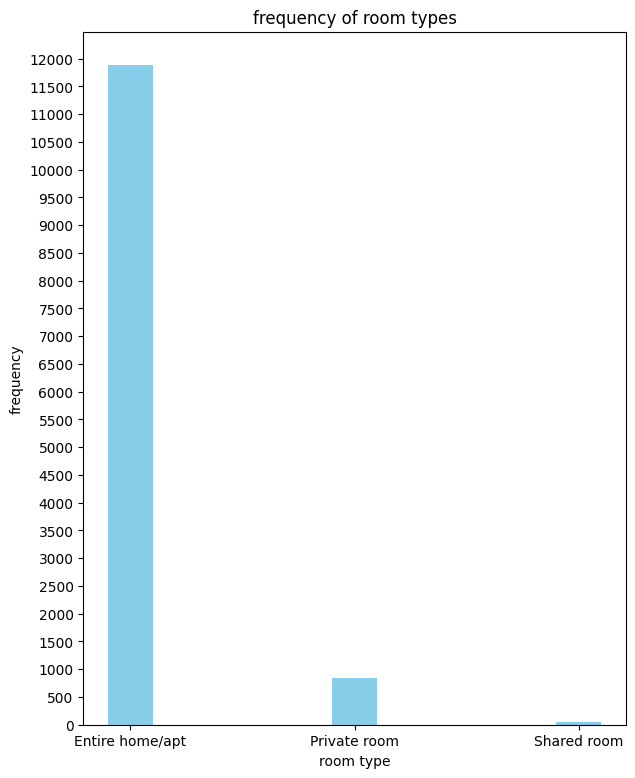

In [ ]:
#EROTIMA 1.1
df = pd.read_csv('train_2019.csv')

#count how many times every room_type exists
room_type_counts = df['room_type'].value_counts()

#make plot
plt.figure(figsize=(7, 9))
plt.bar(room_type_counts.index, room_type_counts.values, color='skyblue',width = 0.2)
plt.xlabel("room type")
plt.ylabel("frequency")
plt.title('frequency of room types')
max_y = room_type_counts.values.max()
plt.yticks(range(0, max_y+500, 500))

#save plot
plt.savefig('question_1_1.png')

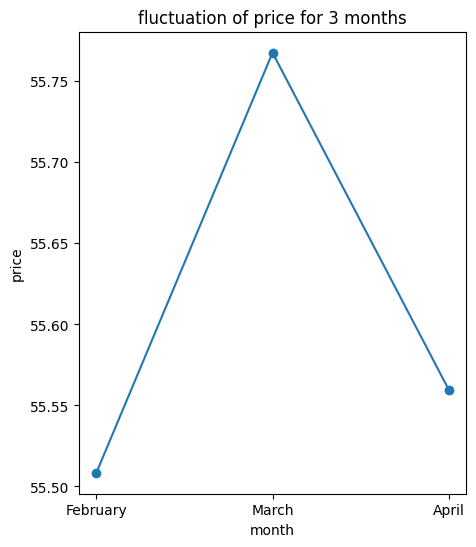

In [ ]:
#EROTIMA 1.2
df = pd.read_csv('train_2019.csv')

#take each month's data
df_feb_2019 = df[df['month'] == 'february']
df_mar_2019 = df[df['month'] == 'march']
df_apr_2019 = df[df['month'] == 'april']

mean_feb_2019 = df_feb_2019['price'].mean()
mean_mar_2019 = df_mar_2019['price'].mean()
mean_apr_2019 = df_apr_2019['price'].mean()

df_2019_range = pd.DataFrame({'month': ['February','March','April'],
                              'price':[mean_feb_2019, mean_mar_2019,
                                       mean_apr_2019]})
#make plot
plt.figure(figsize=(5, 6))
plt.plot(df_2019_range['month'], df_2019_range['price'], marker='o')
plt.xlabel('month')
plt.ylabel('price')
plt.title('fluctuation of price for 3 months')

#save plot
plt.savefig('question_1_2.png')


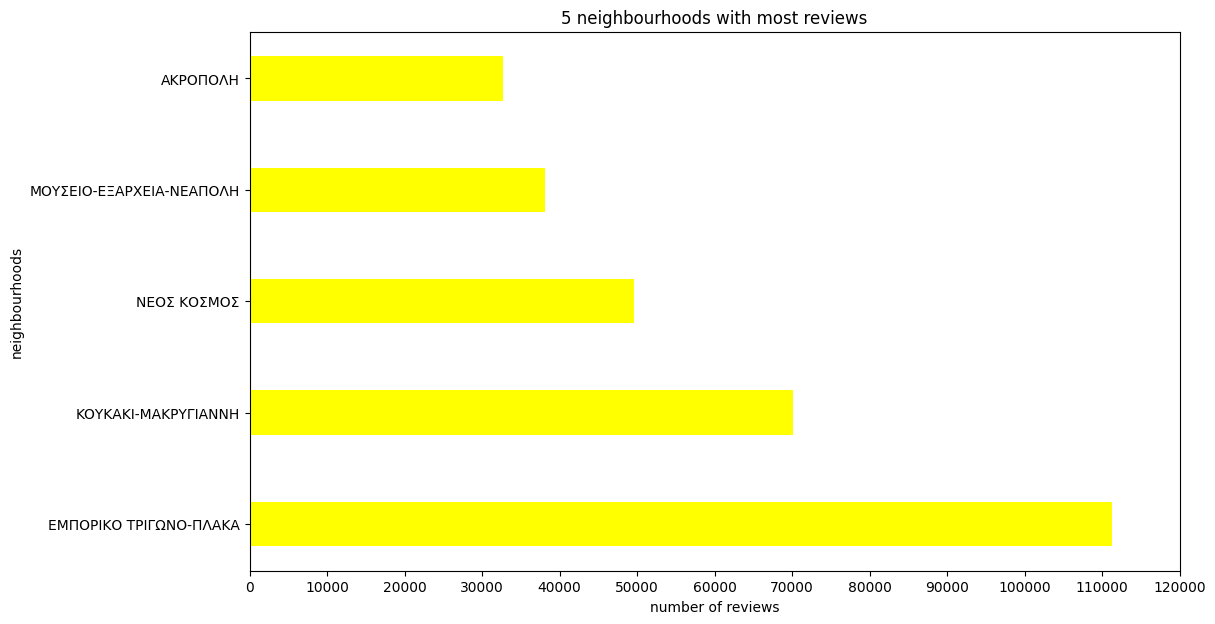

In [ ]:
#EROTIMA 1.3
df = pd.read_csv('train_2019.csv')

#get top 5 neighbourhoods with most reviews
neighbourhoods_with_reviews = df.groupby('neighbourhood_cleansed')['number_of_reviews'].sum()
top_five = neighbourhoods_with_reviews.nlargest(5)

#make plot
plt.figure(figsize=(12, 7))
plt.barh(top_five.index, top_five.values, color = 'yellow', height = 0.4)
plt.xlabel("number of reviews")
plt.ylabel("neighbourhoods")
plt.title('5 neighbourhoods with most reviews')
max_x = top_five.max()
plt.xticks(range(0, max_x+10000, 10000))

#save plot
plt.savefig('question_1_3.png')

In [ ]:
#EROTIMA 1.4
df = pd.read_csv('train_2019.csv')

neighbourhoods = df['neighbourhood_cleansed'].value_counts()
top_neighbourhood = neighbourhoods.head(1)
print(top_neighbourhood)

neighbourhood_cleansed
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ    1822
Name: count, dtype: int64


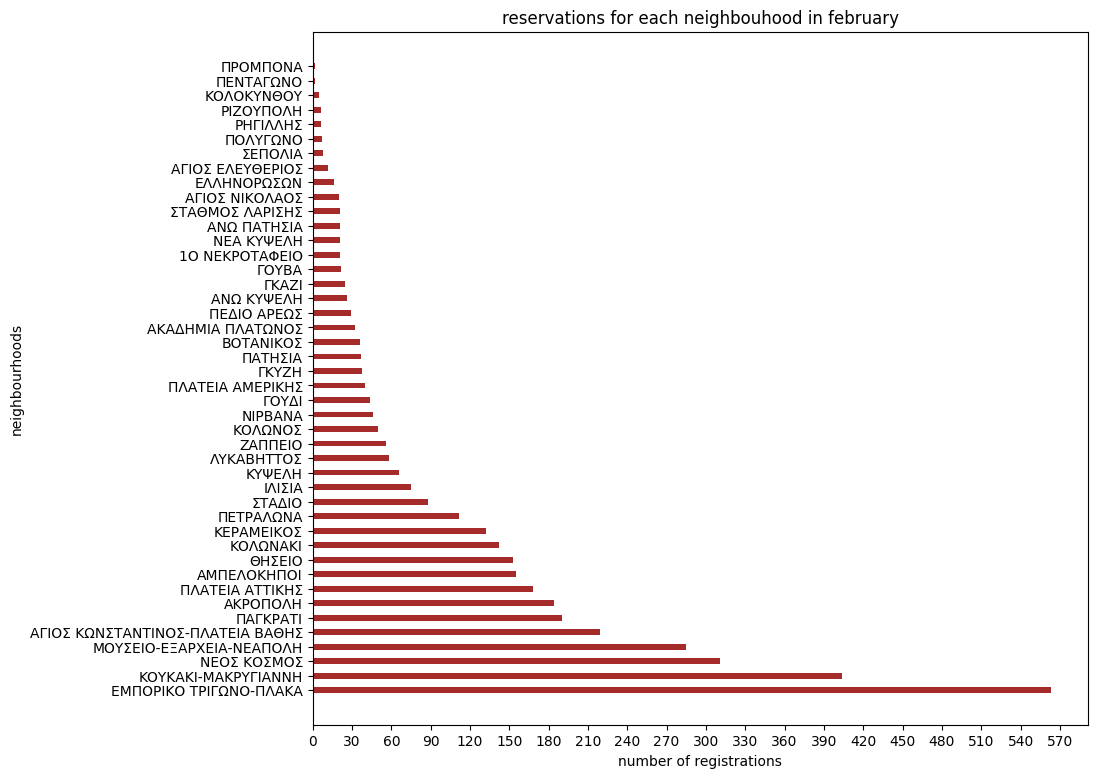

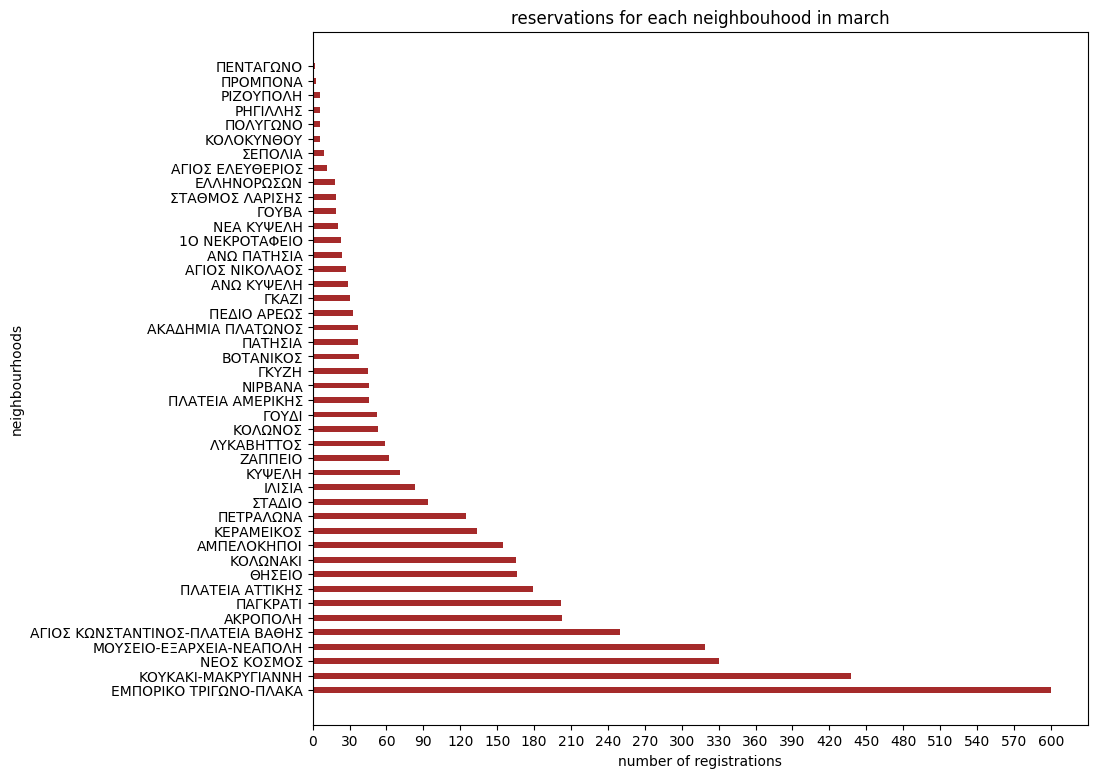

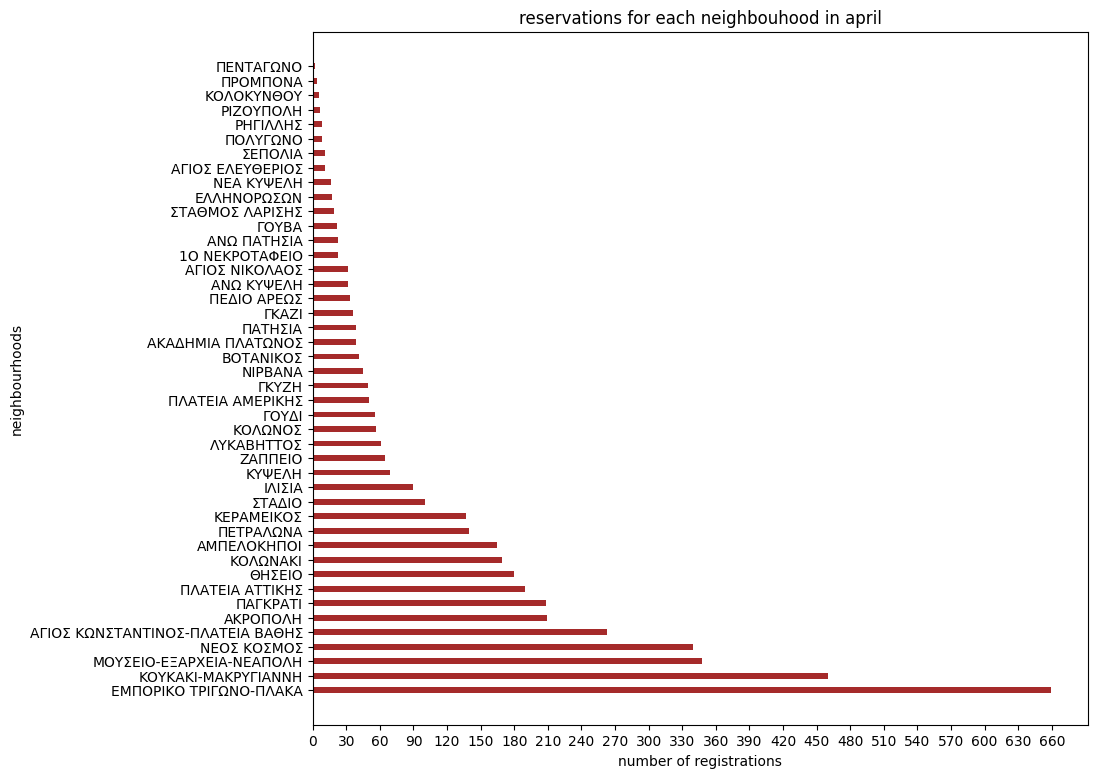

In [ ]:
#EROTIMA 1.5
df = pd.read_csv('train_2019.csv')

reg_df = df.groupby(['month', 'neighbourhood_cleansed']).size()
#make plot for every month
months = ['february', 'march', 'april']
for index,month in enumerate(months):
   monthly = reg_df[month].sort_values(ascending = False)
   plt.figure(figsize=(10, 9))
   plt.barh(monthly.index, monthly.values, color = 'brown', height = 0.4)
   plt.xlabel("number of registrations")
   plt.ylabel("neighbourhoods")
   plt.title('reservations for each neighbouhood in ' + month)
   max_x = monthly.max()
   plt.xticks(range(0, max_x+30, 30))
   name = 'question_1_5_' + str(index + 1) + '.png'

   #save plot
   plt.savefig(name)

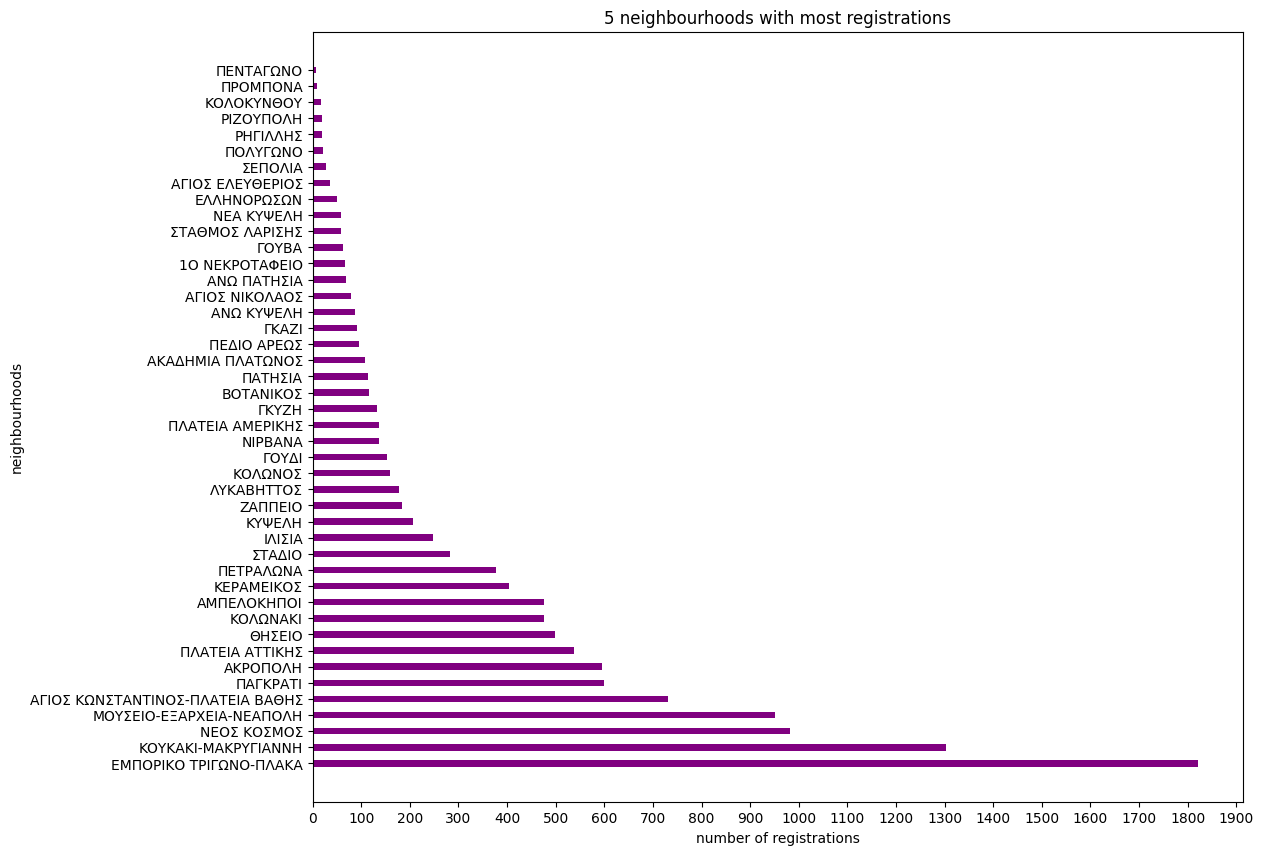

In [ ]:
#EROTIMA 1.6
df = pd.read_csv('train_2019.csv')

top_neighbourhoods = df['neighbourhood_cleansed'].value_counts()

#make plot
plt.figure(figsize=(12, 10))
plt.barh(top_neighbourhoods.index, top_neighbourhoods.values, color = 'purple', height = 0.4)
plt.xlabel("number of registrations")
plt.ylabel("neighbourhoods")
plt.title('5 neighbourhoods with most registrations')
max_x = top_neighbourhoods.max()
plt.xticks(range(0, max_x+100, 100))

#save plot
plt.savefig('question_1_6.png')

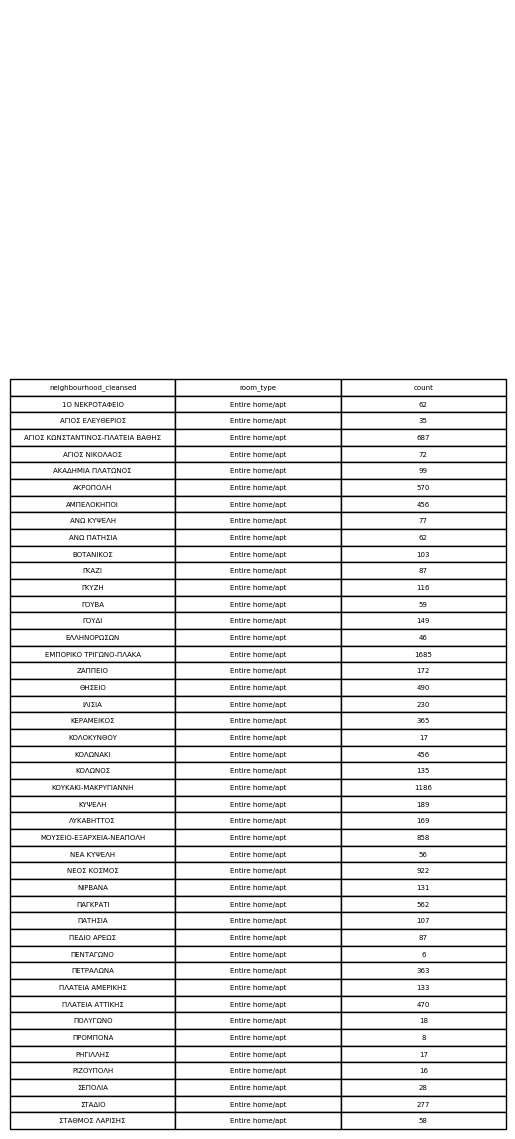

In [ ]:
#EROTIMA 1.7
df = pd.read_csv('train_2019.csv')

#make new column 'count'
freq_df = df.groupby(['neighbourhood_cleansed', 'room_type']).size().reset_index()

freq_df.columns = ['neighbourhood_cleansed', 'room_type', 'count']

#find indexes of most frequent room type for every neighbourhood in freq_df
room_indexes = freq_df.groupby('neighbourhood_cleansed')['count'].idxmax().values

#find data about room_types with the above indexes
room_types = freq_df.loc[room_indexes]

fig, ax = plt.subplots(1, 1)
ax.axis('off')

#make table
ax.table(cellText=room_types.values, colLabels=['neighbourhood_cleansed', 'room_type', 'count'],
         cellLoc = 'center')

#save table
plt.savefig('question_1_7.png')

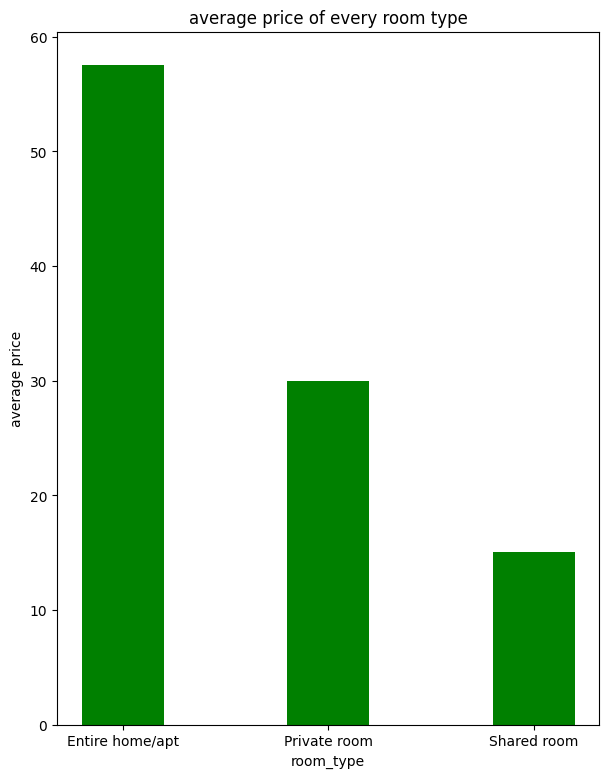

In [ ]:
#EROTIMA 1.8
df = pd.read_csv('train_2019.csv')

avg_prices_df = df.groupby('room_type')['price'].mean()

#make plot
plt.figure(figsize=(7, 9))
plt.bar(avg_prices_df.index, avg_prices_df.values, color='green', width = 0.4)
plt.xlabel('room_type')
plt.ylabel('average price')
plt.title('average price of every room type')

#save plot
plt.savefig('question_1_8.png')

In [ ]:
#EROTIMA 1.9
df = pd.read_csv('train_2019.csv')

#I take the first 1500 because with more data it gets stuck
month_df = df[df['month'] == 'april'].head(1500)

#make map
mapp = folium.Map(location=[month_df['latitude'].mean(), month_df['longitude'].mean()], zoom_start=12.5)

#function to make a marker for every property
def make_marker(row):
    popup_info = f"Bed Type: {row['bed_type']}, Room Type: {row['room_type']}, Transit: {row['transit']}"
    map_popup = folium.Popup(popup_info, max_width=400)
    marker = folium.Marker(location=[row['latitude'], row['longitude']], popup = map_popup)
    marker.add_to(mapp)

#apply make_marker function to every row in the new DataFrame called month_df
month_df.apply(make_marker, axis=1)

#save map
mapp.save('question_1_9.html')

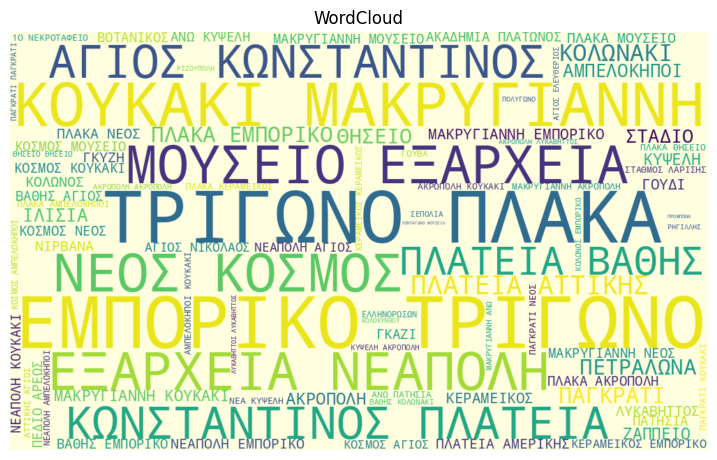

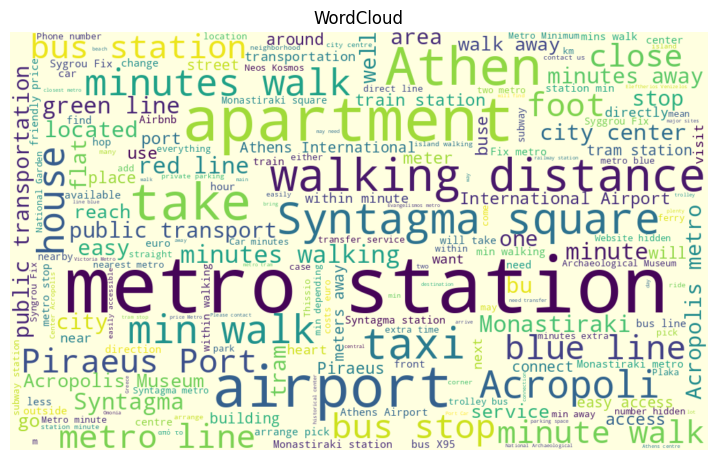

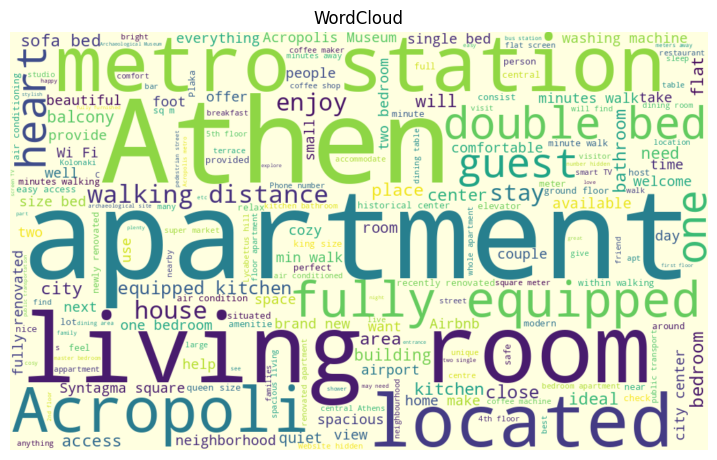

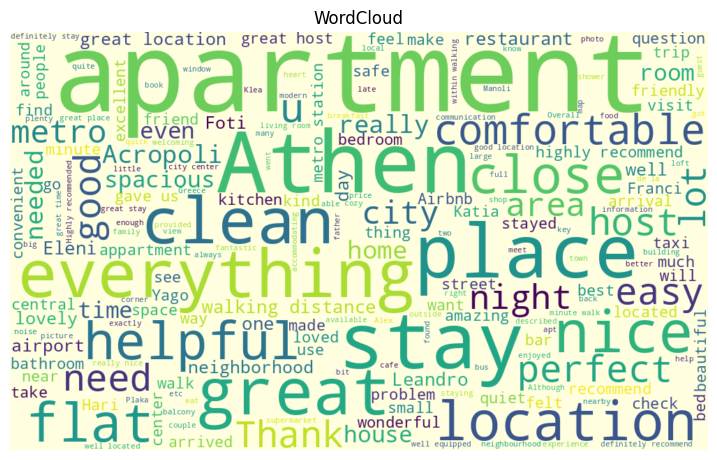

In [ ]:
#EROTIMA 1.10

def make_wordcloud(context, count):

  #make word cloud
  wc = WordCloud(width=1000, height=600, background_color='lightyellow').generate(context)
  plt.figure(figsize=(9, 7))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title('WordCloud')

  #save plot
  plt.savefig('question_1_10_' + str(count) + '.png')

df = pd.read_csv('train_2019.csv')

#make wordclouds for every column asked.
count = 1
context = ' '.join(df['neighbourhood_cleansed'])
make_wordcloud(context, count)
count = count + 1
context = ' '.join(df['transit'])
make_wordcloud(context, count)
count = count + 1
context = ' '.join(df['description'])
make_wordcloud(context, count)
count = count + 1
context = ' '.join(reviews_2019_df['comments'])
make_wordcloud(context, count)

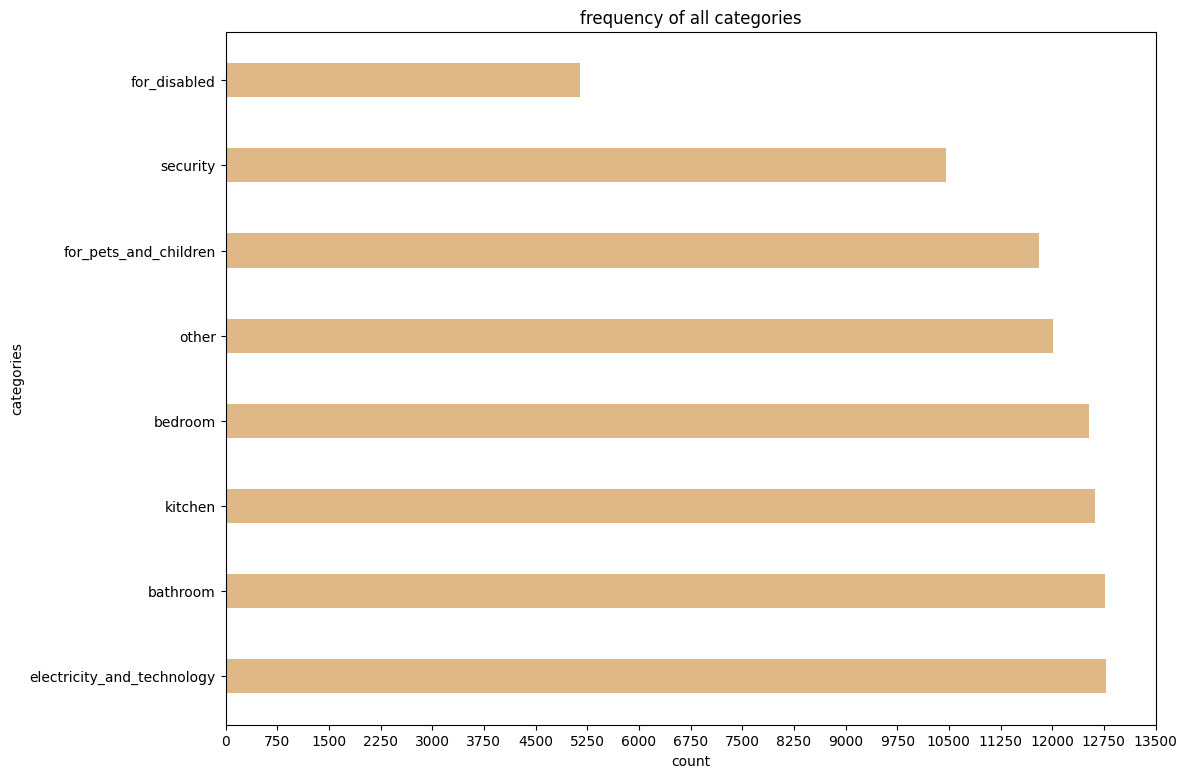

In [ ]:
#EROTIMA 1.11
df = pd.read_csv('train_2019.csv')

df['amenities'] = df['amenities'].str.replace("'", '')
df['amenities'] = df['amenities'].str.replace(' ', '')
category_list = ["kitchen", "bathroom", "electricity_and_technology", "for_pets_and_children",
                 "for_disabled", "bedroom", "security", "other"]

count_dict = {}
for item in category_list:
  count_dict[item] = 0

for index, row in df.iterrows():
  words = df.loc[index, 'amenities'].split(',')
  for i in range(0,len(words)):
    count_dict[words[i]] = count_dict[words[i]] + 1
count_dict= dict(sorted(count_dict.items(), key=lambda item: item[1], reverse=True))
df_2019_dict = pd.DataFrame({'facilities': count_dict.keys(),
                              'count': count_dict.values()})
#make plot
plt.figure(figsize=(12, 9))
plt.barh(df_2019_dict['facilities'], df_2019_dict['count'], color='burlywood', height = 0.4)
plt.xlabel("count")
plt.ylabel("categories")
plt.title('frequency of all categories')
max_x = df_2019_dict['count'].max()
plt.xticks(range(0, max_x+750, 750))

#save plot
plt.savefig('question_1_11.png')



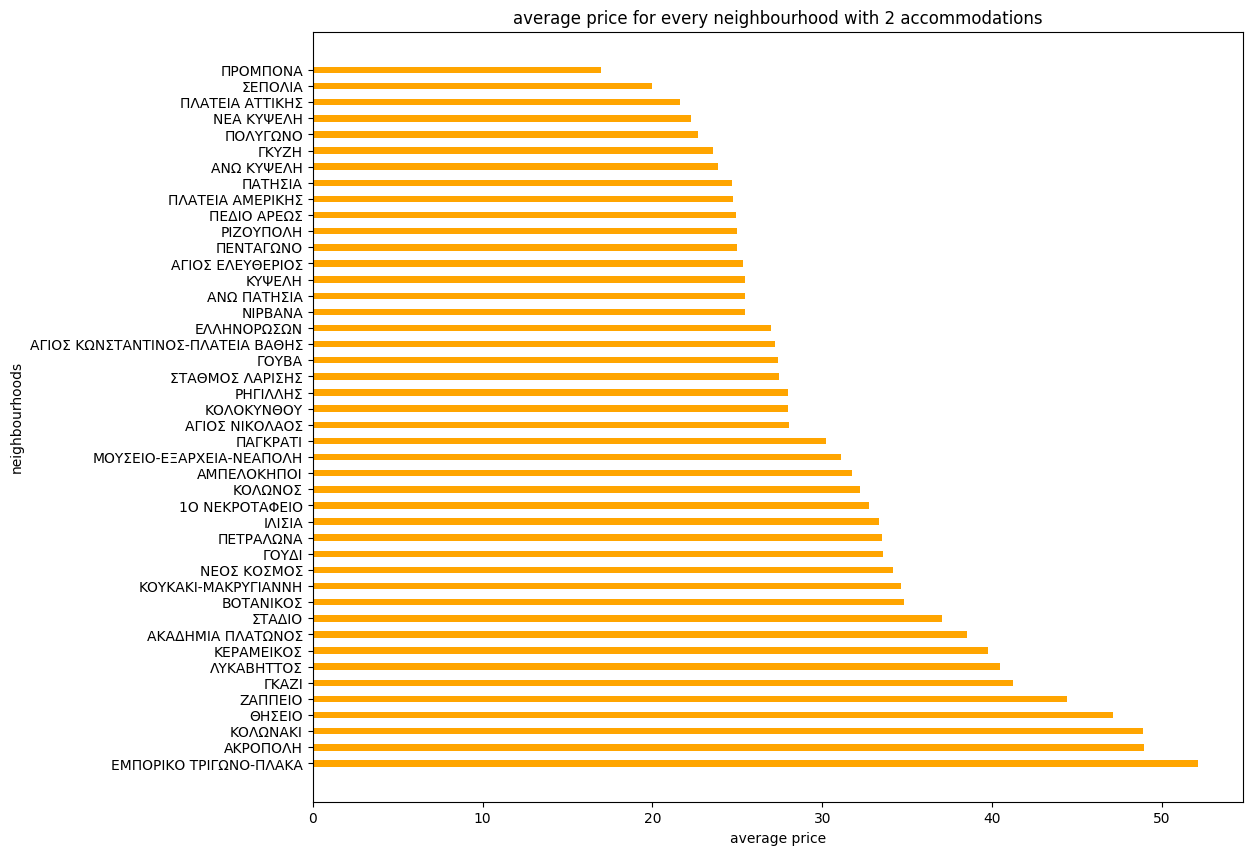

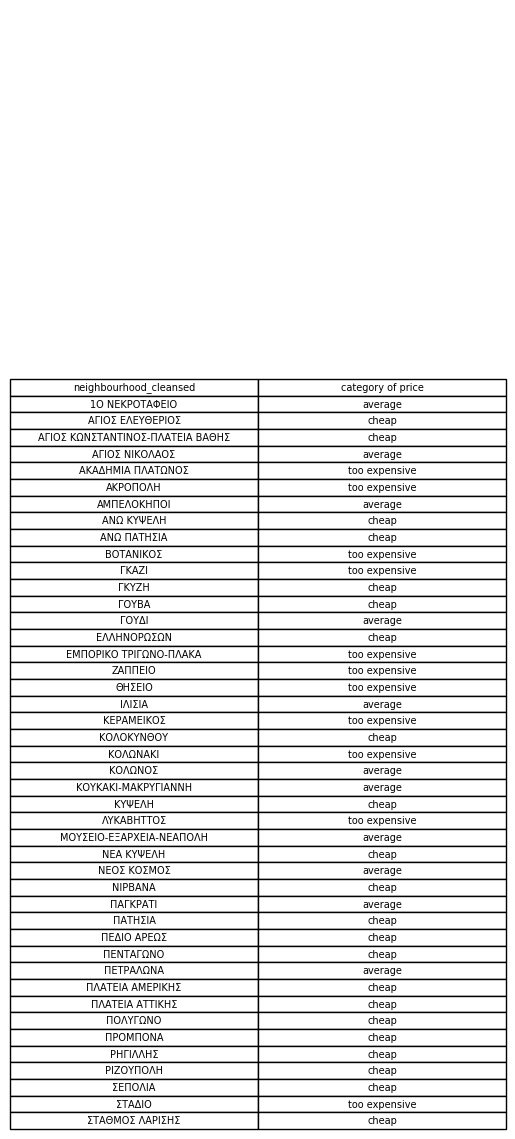

In [ ]:
#EROTIMA 1.12
df = pd.read_csv('train_2019.csv')

avg_df = df[df['accommodates'] == 2]
avg_df = avg_df.groupby('neighbourhood_cleansed')['price'].mean()
avg_df = avg_df.sort_values(ascending = False)

#make plot
plt.figure(figsize=(12, 10))
plt.barh(avg_df.index, avg_df.values, color = 'orange', height = 0.4)
plt.xlabel("average price")
plt.ylabel("neighbourhoods")
plt.title('average price for every neighbourhood with 2 accommodations')

#save plot
plt.savefig('question_1_12_histogram.png')

#define labels for the bins
new_labels = ['cheap', 'average', 'too expensive']

#define bins. cheap will be from the lowest price until the middle etc.
new_bins = [np.min(avg_df), np.percentile(avg_df, 50), np.percentile(avg_df, 75),
        np.max(avg_df)]

#change avg_df so it has a column which shows cheap or average or too expensive for every neighbourhood
avg_df = pd.cut(avg_df, bins = new_bins, labels = new_labels, include_lowest = True)

#get data
avg_df = avg_df.sort_index()
neighbourhoods = avg_df.index
price_categories = avg_df.values

fig, ax = plt.subplots(1, 1)
ax.axis('off')

#make table
table_data = list(zip(neighbourhoods, price_categories))
ax.table(cellText=table_data, colLabels=['neighbourhood_cleansed', 'category of price'],
         cellLoc = 'center')

#save table
plt.savefig('question_1_12_table.png')


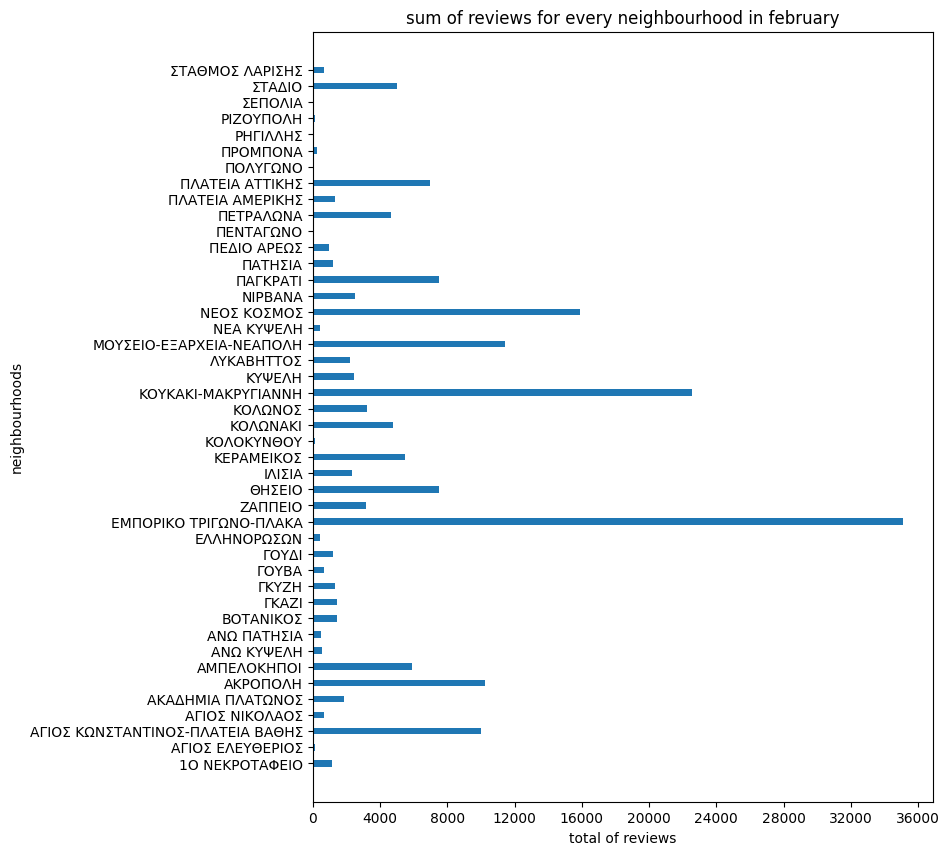

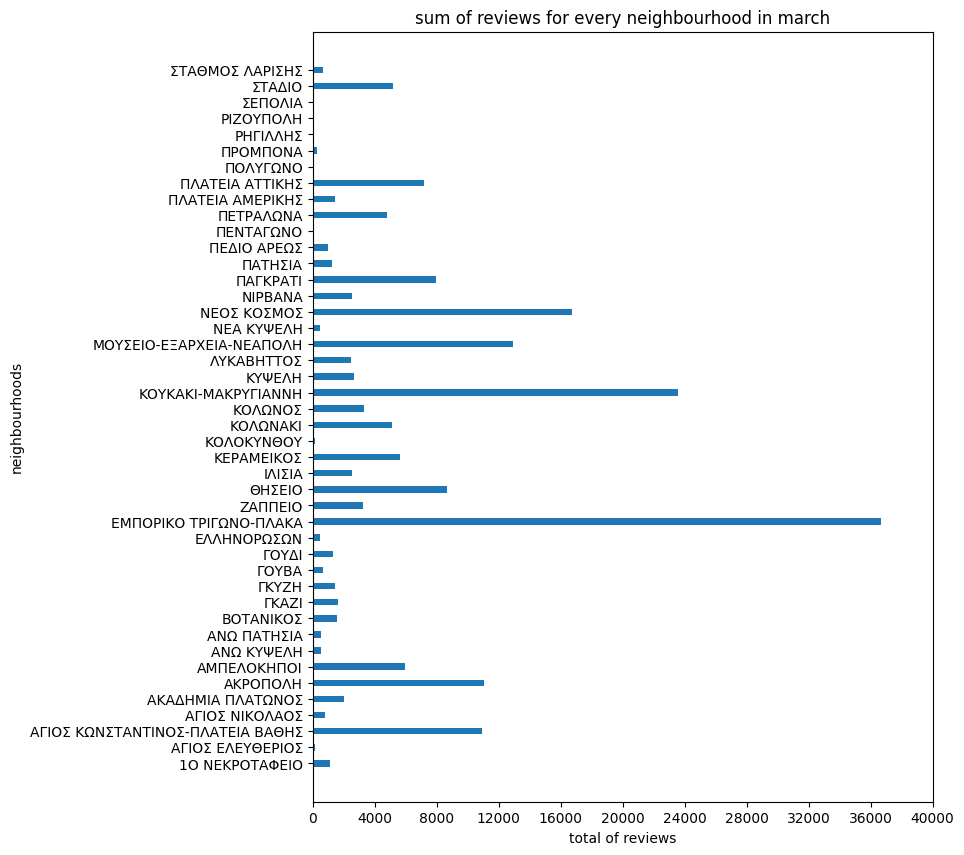

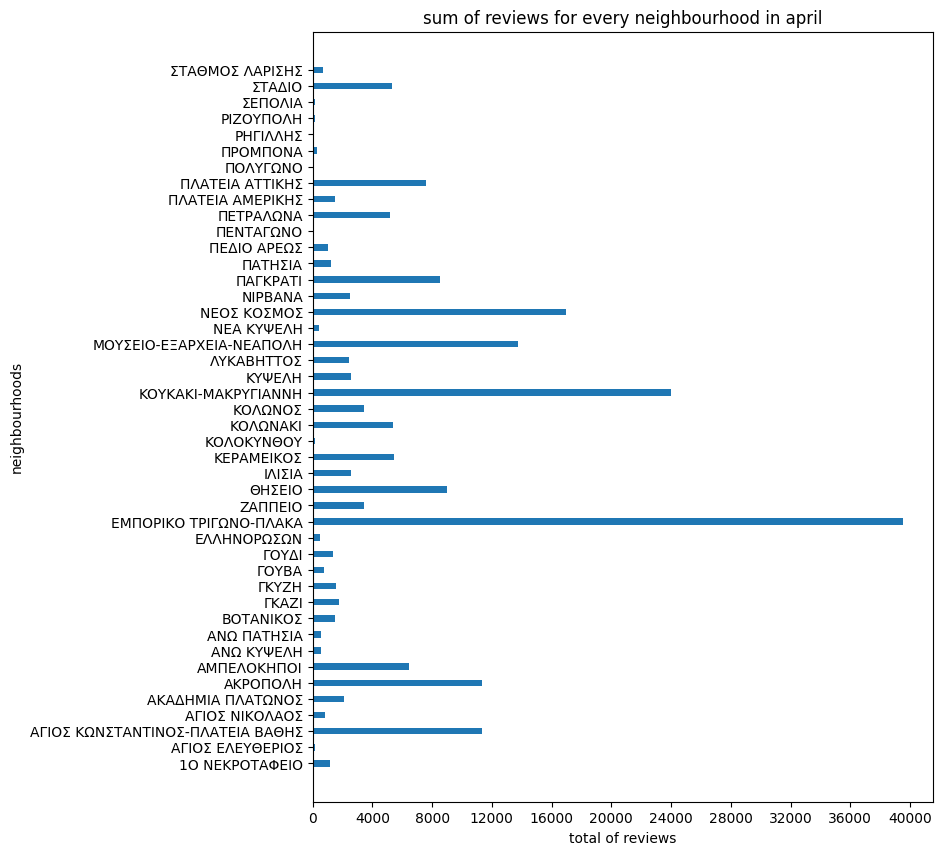

In [ ]:
#EROTIMA 1.13

#EROTIMA A: Σχεδιάστε διάγραμμα με τον αριθμό των κριτικών ανά γειτονιά ανά μήνα
df = pd.read_csv('train_2019.csv')

for index, month in enumerate(['february', 'march', 'april']):
  review_df = df[df['month'] == month]
  review_df = review_df.groupby('neighbourhood_cleansed')['number_of_reviews'].sum()

  #make plot
  plt.figure(figsize=(8, 10))
  plt.barh(review_df.index, review_df.values, height = 0.4)
  max_x = review_df.max()
  plt.xticks(range(0, max_x+4000, 4000))
  plt.xlabel('total of reviews')
  plt.ylabel('neighbourhoods')
  plt.title('sum of reviews for every neighbourhood in '+ str(month))

  #save plot
  plt.savefig('question_1_13A_' + str(index + 1) + '.png')

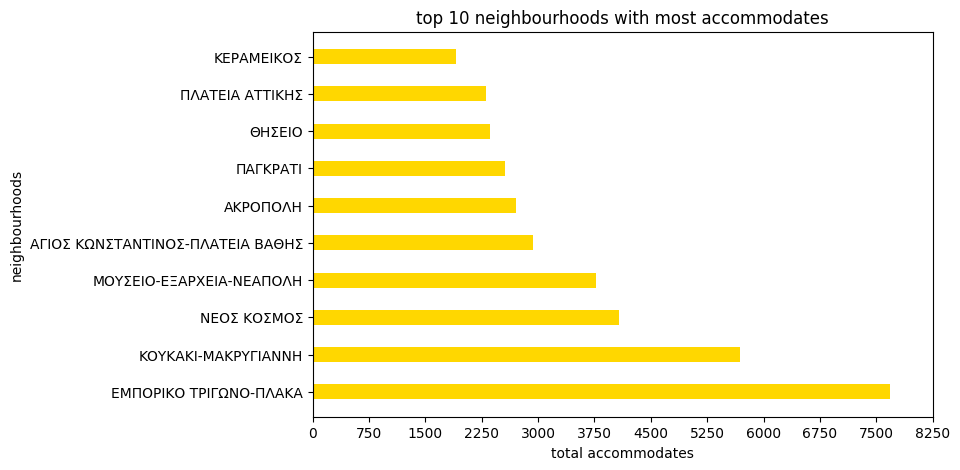

In [ ]:
#EROTIMA 1.13

#EROTIMA Β: Σχεδιάστε διάγραμμα με τις πρώτες 10 γειτονιές που μπορούν να φιλοξενήσουν τα περισσότερα άτομα
df = pd.read_csv('train_2019.csv')

accom_df = df.groupby('neighbourhood_cleansed')['accommodates'].sum()

accom_df = accom_df.sort_values(ascending=False).head(10)

#make plot
plt.figure(figsize=(8, 5))
plt.barh(accom_df.index, accom_df.values, color = 'gold', height = 0.4)
max_x = accom_df.max()
plt.xticks(range(0, max_x+750, 750))
plt.xlabel("total accommodates")
plt.ylabel("neighbourhoods")
plt.title('top 10 neighbourhoods with most accommodates')

#save plot
plt.savefig('question_1_13B.png')


In [ ]:
#EROTIMA 1.13

#EROTIMA C: Βρείτε το id, τη τιμή και τον μήνα του πιο ακριβού διαμερίσματος
df = pd.read_csv('train_2019.csv')

#make new indexes and drop the old ones
df = df.reset_index(drop=True)

#find index of most expensive property
max_index = df['price'].idxmax()

#get data of row with index == max_index
max_res = df.loc[max_index]

#print the information asked
print('id is:', max_res['id'])
print('price is:', max_res['price'])
print('month is:', max_res['month'])

id is: 22800822
price is: 800.0
month is: february


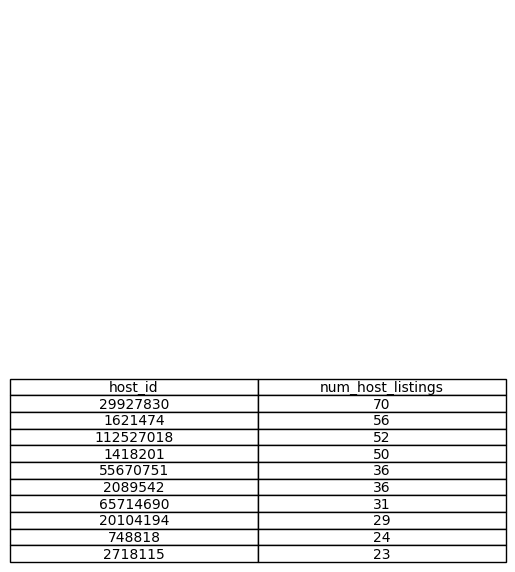

In [ ]:
#EROTIMA 1.14
df = pd.read_csv('train_2019.csv')

#find top 10 hosts with most properties
host_df = df.groupby('host_id')['id'].nunique()
host_df = host_df.sort_values(ascending = False).head(10)

fig, ax = plt.subplots(1, 1)
ax.axis('off')

#make table
ax.table(cellText=list(zip(host_df.index, host_df.values)), colLabels=['host_id', 'num_host_listings'],
         cellLoc = 'center')

#save plot
plt.savefig('question_1_14.png')

#EROTIMA 1.15
Παρατηρούμε ότι οι τιμές στην περιοχή της Αθήνας αυξήθηκαν αρκετά. Συγκεκριμένα τον Ιούνιο του 2023 οι τιμές σχεδόν διπλασιάστηκαν σε σχέση με το 2019. Από επόμενο ερώτημα μπορούμε να εξάγουμε το εξής συμπέρασμα για τις παρακάτω γειτονιές:
1ο ΝΕΚΡΟΤΑΦΕΙΟ average -> too expensive,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ cheap -> average,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ average -> cheap,
ΑΚΑΔΗΜΙΑ ΠΛΑΤΩΝΟΣ too expensive -> cheap,
ΑΜΠΕΛΟΚΗΠΟΙ average -> cheap,
ΒΟΤΑΝΙΚΟΣ too expensive -> cheap, ΖΑΠΠΕΙΟ too expensive -> average, ΚΕΡΑΜΕΙΚΟΣ too expensive -> average,ΚΟΛΩΝΟΣ average -> cheap,
ΚΟΥΚΑΚΙ average -> too expensive,
ΠΕΔΙΟ ΑΡΕΩΣ cheap -> average,
ΠΕΝΤΑΓΩΝΟ δεν υπάρχει στο 2023,
ΠΡΟΜΠΟΝΑ cheap -> too expensive,
ΡΗΓΙΛΛΗΣ cheap -> too expensive.
Όλες οι υπόλοιπες γειτονιές παρέμειναν στην ίδια κατηγορία τιμών και τα 2 έτη. Επίσης, προκύπτει το συμπέρασμα ότι οι τιμές για το entire home/apt αυξήθηκαν σημαντικά το 2023, όπως και για τα private_room, shared_room, ενώ το 2023 υπάρχουν καταχωρήσεις για ένα νέο τύπο δωματίου, τον hotel_room που είναι και ο πιο ακριβός για το συγκεκριμένο έτος με σχεδόν διπλάσια τιμή από τον αμέσως επόμενο τύπου δωματίου.

In [ ]:
#EROTIMA 2.3
def recommend(item_id, num):

  if item_id not in df.index:
    print("Id you gave does not exist.")
    return

  #get the first num similar indexes for the item_id given
  similar_indexes = similarity_dict[item_id][:num]

  name_id = df.loc[item_id, 'name']
  print(f"Recommending {num} listings similar to {name_id}")
  print("--------------------")
  print()

  for index in similar_indexes:
    name = df.iloc[index]['name']
    description = df.iloc[index]['description']
    similarity_score = similarity[item_id][index]
    print(f"Recommended: {name}")
    print(f"Description: {description}")
    print(f"(score: {similarity_score})")
    print()


In [ ]:

#EROTIMA 2.1
df = pd.read_csv('train_2019.csv')

#create new column 'name description' from columns 'name' and 'description' and fill NA with NULL
df['name_description'] = df['name'].fillna('NULL') + ' ' + df['description'].fillna('NULL')

#remove duplicates from 'name description'
df.drop_duplicates(subset='name_description', inplace=True)

#get rid of STOP_WORDS and create the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words = list(text.ENGLISH_STOP_WORDS), ngram_range = (1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['name_description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns = tfidf_vectorizer.get_feature_names_out())

#print top 5 words that visitors use for Athens
most_used_words = tfidf_df.sum().sort_values(ascending = False).head(5)
print('Top 5 most used words are:')
print(most_used_words)

#EROTIMA 2.2
#make the tfidf values to a CSR sparse matrix
sparse = csr_matrix(tfidf_df.values)

#take the tfidf indexes
indexes = tfidf_df.index
similarity_dict = {}

#compute cosine similarity between all combinations
similarity = cosine_similarity(sparse)

for item_id in indexes:
  #get similarities for each item_id
  similarities = similarity[item_id]

  #sort similarities in ascending order
  similarities = np.argsort(similarities)

  #reverse them so they will be in descending order
  similarities = similarities[::-1]

  #take the first 101 items
  similarities = similarities[:101]

  #remove the case index == item_id
  similarity_dict[item_id] = [index for index in similarities if index != item_id]

#get rid of every id that not exists in DataFrame
similarity_dict = {item_id: similarities for item_id, similarities in similarity_dict.items() if item_id in df.index}

item_id = int(random.choice(list(similarity_dict.keys())))
num = int(input("How many recommandations do you want? "))
recommend(item_id, num)

#EROTIMA 2.4
#make all uppercase letters to lowercase
df_lower = df['name_description'].str.lower()

#seperate all words by whitespace
all_words = df_lower.str.split()

#make all lists of words into one big list
words = []
for list_words in all_words:
    for word in list_words:
        words.append(word)

#remove stopwords from words
stop_words = set(text.ENGLISH_STOP_WORDS)
words_without_stopwords = []

for word in words:
  if word not in stop_words:
    words_without_stopwords.append(word)

#find top 10 matching words
finder = BigramCollocationFinder.from_words(words_without_stopwords)
bigram_measures = BigramAssocMeasures()
collocations = finder.nbest(bigram_measures.raw_freq, 10)
print('Top 10 collocations of words are:')
print(collocations)

Top 5 most used words are:
apartment    198.911208
athens       143.139144
acropolis    124.060135
metro        103.572567
room         103.007458
dtype: float64
How many recommandations do you want? 8
Recommending 8 listings similar to Oasis Loft Center Athens Walk Acropolis freebrunch
--------------------

Recommended: BohemianLoft Center Athens walk Acropolis brunch!
Description: Please see our second listing for more dates! https://www.airbnb.com/rooms/18102581?preview_for_ml Homemade BREAKFAST/BRUNCH IS INCLUDED. Eating this breakfast at a restaurant is approximately 10 euros p.p.    Stay with locals, come in a chilled home with smells of food,  vibrant conversation and a chilled atmosphere than to come in an empty house or apartment.  A home away from home!!!Thats how we love to travel as well and share that experience with other travellers!! Come to our hub! This is a New York style loft, which means it's an open floor plan (there are no doors that divide the space) it includes 